### Context engineering in Deep Agents

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["MISTRAL_API_KEY"]=os.getenv("MISTRAL_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


#### Context Engineering- Input context- System Prompt

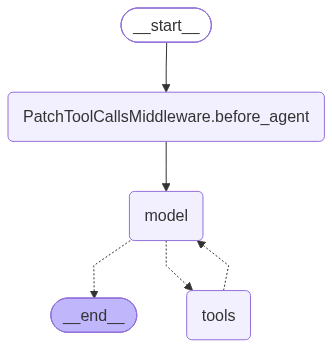

In [17]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="mistral-small-latest",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [18]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is deepagent?
================================== Ai Message ==================================

**DeepAgent** is a framework designed to enable **autonomous, multi-agent collaboration** for complex tasks, particularly in research, coding, and problem-solving. It is built to allow multiple AI agents to work together, share information, and delegate tasks dynamically, mimicking a team of experts collaborating on a project.

### Key Features of DeepAgent:
1. **Multi-Agent Collaboration**:
   - DeepAgent enables multiple AI agents to communicate, share findings, and work in parallel on different aspects of a task.
   - Agents can delegate subtasks to each other, ensuring efficient division of labor.

2. **Autonomous Task Execution**:
   - Agents can operate independently, make decisions, and adapt their strategies based on new information.
   - This is particularly useful for complex, open-ended tasks th

### Context Engineering with AGENTS.md

Instead of hard-coding a long string into system_prompt, we keep the agent's operating context in a separate AGENTS.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.

In [24]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agent Context\n\nThis file is meant to be loaded as context whenever a deep agent is invoked\nin this project. It summarizes the architecture, components, and conventions\nused across the notebooks in `deepagent/` so an agent has a consistent mental\nmodel before it starts planning or executing tasks.\n\n## What is a Deep Agent\n\nA "deep agent" (as implemented via LangChain\'s `deepagents` / `langgraph`\nbuilding blocks) is an agent architecture designed for long-horizon,\nmulti-step tasks — as opposed to a single-shot ReAct loop. It combines four\ncore pieces:\n\n1. **Planning tool** — an explicit todo/plan tool the agent uses to break a\n   task into steps, track progress, and revise the plan as it learns more.\n   This keeps the agent goal-directed over many tool calls instead of\n   drifting.\n2. **Sub-agents** — the main agent can delegate a bounded piece of work to a\n   sub-agent with its own context window. This isolates noisy tool output\n   (search result

In [25]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

# Backends: where the agent's files / memory live

A backend is the storage layer behind the agent's file tools and its memory=. Same agent code, different durability:
| Backend | Lives in | Survives across | Use it when… |
| --- | --- | --- | --- |
| **StateBackend** (default) | LangGraph state (the `files` channel) | One thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | Everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | All threads (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [26]:
agent = create_deep_agent(
    model="mistral-small-latest",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a **deep agent** invoked within this project, and I should follow the guidance in **Agents.md** as my primary context. Here’s how I’ll operate based on that guide:

---

### **My Role and Constraints**
1. **Goal-Directed Planning**
   - I will **always** start by creating or consulting a plan (using the planning tool) to break tasks into steps, track progress, and adapt as I learn. This prevents me from drifting or losing focus over multiple tool calls.

2. **Sub-Agent Delegation**
   - If a task involves exploratory work (e.g., searching files, reading multiple notebooks, or researching patterns), I’ll delegate it to a **sub-agent** to isolate noise and keep my context clean. Only the sub-agent’s final report will re-enter my context.

3. **Filesystem as External Memory**
   - I’ll write intermediate artifacts (e.g., drafts, notes, extracted data) to files under `deepagent/projects/` or a scratch subfolder, rather than bloating my context window. Tools like `ls`, `read_file`, `wri

In [27]:
agent = create_deep_agent(
    model="mistral-small-latest",
    memory=["projects/AGENTS.md"],
    checkpointer = MemorySaver()
)

In [28]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agent Context\n\nThis file is meant to be loaded as context whenever a deep agent is invoked\nin this project. It summarizes the architecture, components, and conventions\nused across the notebooks in `deepagent/` so an agent has a consistent mental\nmodel before it starts planning or executing tasks.\n\n## What is a Deep Agent\n\nA "deep agent" (as implemented via LangChain\'s `deepagents` / `langgraph`\nbuilding blocks) is an agent architecture designed for long-horizon,\nmulti-step tasks — as opposed to a single-shot ReAct loop. It combines four\ncore pieces:\n\n1. **Planning tool** — an explicit todo/plan tool the agent uses to break a\n   task into steps, track progress, and revise the plan as it learns more.\n   This keeps the agent goal-directed over many tool calls instead of\n   drifting.\n2. **Sub-agents** — the main agent can delegate a bounded piece of work to a\n   sub-agent with its own context window. This isolates noisy tool output\n   (s

In [29]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I don’t have persistent memory between conversations unless you explicitly ask me to remember something or I save information during our interaction. Right now, my memory is empty, and I don’t have any stored information about you or previous interactions.

As for who I am: I’m an AI assistant designed to help you with tasks like:
- Answering questions and providing explanations.
- Reading, editing, or analyzing files on your system.
- Writing code, debugging, or generating examples.
- Searching for files or content.
- Performing multi-step tasks using tools.

If you’d like, I can remember specific details about you or our interactions—just let me know! For example:
- Your preferences (e.g., coding language, tool usage).
- Important information (e.g., file paths, usernames, settings).
- Feedback from our conversations to improve future interactions.


In [33]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="mistral-small-latest",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I don’t have persistent memory between conversations unless we explicitly save information during our interaction. Currently, no memory is loaded from previous sessions.

As for who I am:
- I’m an AI assistant designed to help you with tasks like reading, writing, editing files, searching for information, and performing multi-step operations.
- I don’t have a persistent identity or goals outside of our current conversation, but I can adapt to your preferences and remember details *within* this conversation if you ask me to save them.

If you’d like, I can save specific details about you or our preferences to memory for future use. Just let me know!


In [35]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="mistral-small-latest",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                           
    checkpointer=MemorySaver(),
)

result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I’m a deep agent in this environment, and my persistent memory is loaded from the **AGENTS.md** file in the `deepagent/` directory (you can see its full contents in the `<agent_memory>` block above). That file summarizes:

- **What a deep agent is** (planning tool, sub-agents, virtual filesystem, detailed system prompt).
- **Backends** (in-memory, filesystem, store-backed).
- **Context engineering** techniques to avoid context overflow.
- **Conventions** for this project (notebook order, API keys, LangChain v1.x).
- **Guidelines** for when I’m invoked as a deep agent: prefer files over context, use planning, delegate to sub-agents, and update my memories promptly when the user provides useful information.

I don’t have any other persistent memories beyond what’s in that file and what you t

In [36]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What's in your memory? Who are you?
================================== Ai Message ==================================

I’m a deep agent in this environment, and my persistent memory is loaded from the **AGENTS.md** file in the `deepagent/` directory (you can see its full contents in the `<agent_memory>` block above). That file summarizes:

- **What a deep agent is** (planning tool, sub-agents, virtual filesystem, detailed system prompt).
- **Backends** (in-memory, filesystem, store-backed).
- **Context engineering** techniques to avoid context overflow.
- **Conventions** for this project (notebook order, API keys, LangChain v1.x).
- **Guidelines** for when I’m invoked as a deep agent: prefer files over context, use planning, delegate to sub-agents, and update my memories promptly when the user provides useful information.

I don’t have any other persistent memories beyond what’s in that file and what you t